In [4]:
rhos = [5,1,0,0.2,0.04,0.008]
models = ["CE_rho" + str(rho) for rho in rhos]
import sys
sys.path.append('..')
from configs import env
models_paths = [env.MODELS_ROOT + "/" + model for model in models]
file_names = ['/RDM_CE_rho' + str(rho) + '.pt' for rho in rhos]
file_paths = [model_path + '/RDM_CE_rho' + str(rho) + '.pt' for model_path, rho in zip(models_paths, rhos)]

In [5]:
import torch
fixed_path = file_paths[2]
rdm_file = torch.load(fixed_path)
print(fixed_path)
rdms_upper = rdm_file['rdms_upper']
rdms_upper

/home/vlr/Workspaces/Topographic/ConTopo/save/ResNet18/models/CE_rho0/RDM_CE_rho0.pt


[tensor([0.2316, 0.1624, 0.3214,  ..., 0.3196, 0.6390, 0.7556]),
 tensor([0.4394, 0.4230, 0.4541,  ..., 0.0975, 0.2388, 0.1859]),
 tensor([0.3729, 0.3312, 0.2395,  ..., 0.1254, 0.5126, 0.6117]),
 tensor([0.1182, 0.1740, 0.1584,  ..., 0.0360, 0.5788, 0.6496]),
 tensor([0.0494, 0.1261, 0.0707,  ..., 0.0670, 0.1703, 0.1542]),
 tensor([0.1383, 0.1458, 0.2146,  ..., 0.5717, 0.1803, 0.6418]),
 tensor([0.1902, 0.1511, 0.2861,  ..., 0.0718, 0.1155, 0.2133]),
 tensor([0.1237, 0.0914, 0.1485,  ..., 0.0357, 0.6177, 0.6400]),
 tensor([0.2560, 0.0536, 0.3293,  ..., 0.1250, 0.2701, 0.4065]),
 tensor([0.1836, 0.1888, 0.1963,  ..., 0.0248, 0.2496, 0.2638])]

In [6]:
import polars as pl
df = pl.from_dict({str(i): t.tolist() for i,t in enumerate(rdms_upper)})
rdms_corr = df.corr()
rdms_corr

0,1,2,3,4,5,6,7,8,9
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.82748,0.824944,0.829016,0.823993,0.842084,0.828388,0.831982,0.820178,0.841312
0.82748,1.0,0.831464,0.840162,0.840146,0.840359,0.840527,0.834528,0.831803,0.851521
0.824944,0.831464,1.0,0.827448,0.835705,0.849031,0.828088,0.848368,0.829365,0.846512
0.829016,0.840162,0.827448,1.0,0.827105,0.835095,0.84283,0.834984,0.826681,0.83368
0.823993,0.840146,0.835705,0.827105,1.0,0.829788,0.830545,0.834632,0.830953,0.83908
0.842084,0.840359,0.849031,0.835095,0.829788,1.0,0.83639,0.850015,0.833807,0.845272
0.828388,0.840527,0.828088,0.84283,0.830545,0.83639,1.0,0.832023,0.828907,0.843959
0.831982,0.834528,0.848368,0.834984,0.834632,0.850015,0.832023,1.0,0.829661,0.843362
0.820178,0.831803,0.829365,0.826681,0.830953,0.833807,0.828907,0.829661,1.0,0.830763


In [ ]:
import numpy as np
rdms_corr_np = rdms_corr.to_numpy()
upper_vals = rdms_corr_np[np.triu_indices_from(rdms_corr_np, k=1)]
mean = upper_vals.mean()
# Double check
cons_file_names = ['/RDMConsistency_CE_rho' + str(rho) + '.pt' for rho in rhos]
cons_file_paths = [model_path + '/RDMConsistency_CE_rho' + str(rho) + '.pt' for model_path, rho in zip(models_paths, rhos)]
fixed_cons_path = cons_file_paths[2]
print(fixed_cons_path)
cons_file = torch.load(fixed_cons_path)
print(f"{mean:.3f}, {cons_file['mean']:.3f}")

/home/vlr/Workspaces/Topographic/ConTopo/save/ResNet18/models/CE_rho0/RDMConsistency_CE_rho0.pt
0.835, 0.835


In [8]:
import exp_diversity as ed
import pandas as pd

scalar, pw = ed.get_diversity_results_by_ensemble_name("CE_rho0")

print(pw.keys())
display(pd.DataFrame(pw["disagreement"]).head())

dict_keys(['q_statistic', 'double_fault', 'disagreement', 'interrater_agreement', 'correlation', 'iou_top_n'])


,0,1,2,3,4,5,6,7,8,9
0,0.0000,0.0836,0.0858,0.0841,0.0841,0.0809,0.0859,0.0821,0.0820,0.0814
1,0.0836,0.0000,0.0812,0.0787,0.0759,0.0785,0.0747,0.0791,0.0776,0.0746
2,0.0858,0.0812,0.0000,0.0799,0.0769,0.0805,0.0797,0.0803,0.0792,0.0816
3,0.0841,0.0787,0.0799,0.0000,0.0780,0.0794,0.0776,0.0792,0.0773,0.0815
4,0.0841,0.0759,0.0769,0.0780,0.0000,0.0744,0.0738,0.0778,0.0761,0.0767


In [9]:
import numpy as np
import pandas as pd
# Get indices for the upper triangle (k=1 excludes diagonal)
rows, cols = np.triu_indices_from(rdms_corr_np, k=1)

# Build data dictionary
data = {
    "rdms_consistency": rdms_corr_np[rows, cols]
}
display(pd.DataFrame(data).head())

,rdms_consistency
0,0.827480
1,0.824944
2,0.829016
3,0.823993
4,0.842084


In [10]:
# Add diversity metrics
for metric_name, matrix in pw.items():
    mat_np = np.array(matrix)
    data[metric_name] = mat_np[rows, cols]
data
display(pd.DataFrame(data).head())

/tmp/ipykernel_63683/852073191.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  mat_np = np.array(matrix)


,rdms_consistency,q_statistic,double_fault,disagreement,interrater_agreement,correlation,iou_top_n
0,0.827480,0.917196,0.0463,0.0836,0.479748,0.480019,0.690866
1,0.824944,0.914583,0.0476,0.0858,0.478799,0.478802,0.703022
2,0.829016,0.914870,0.0454,0.0841,0.473148,0.473566,0.689861
3,0.823993,0.914593,0.0452,0.0841,0.472066,0.472535,0.684432
4,0.842084,0.924807,0.0479,0.0809,0.497829,0.498060,0.736010


Spearman Correlation with Consistency:
                      rdms_consistency
rdms_consistency              1.000000
iou_top_n                     0.446377
correlation                   0.389723
interrater_agreement          0.384321
q_statistic                   0.367721
double_fault                  0.172526
disagreement                 -0.297707


NameError: name 'os' is not defined

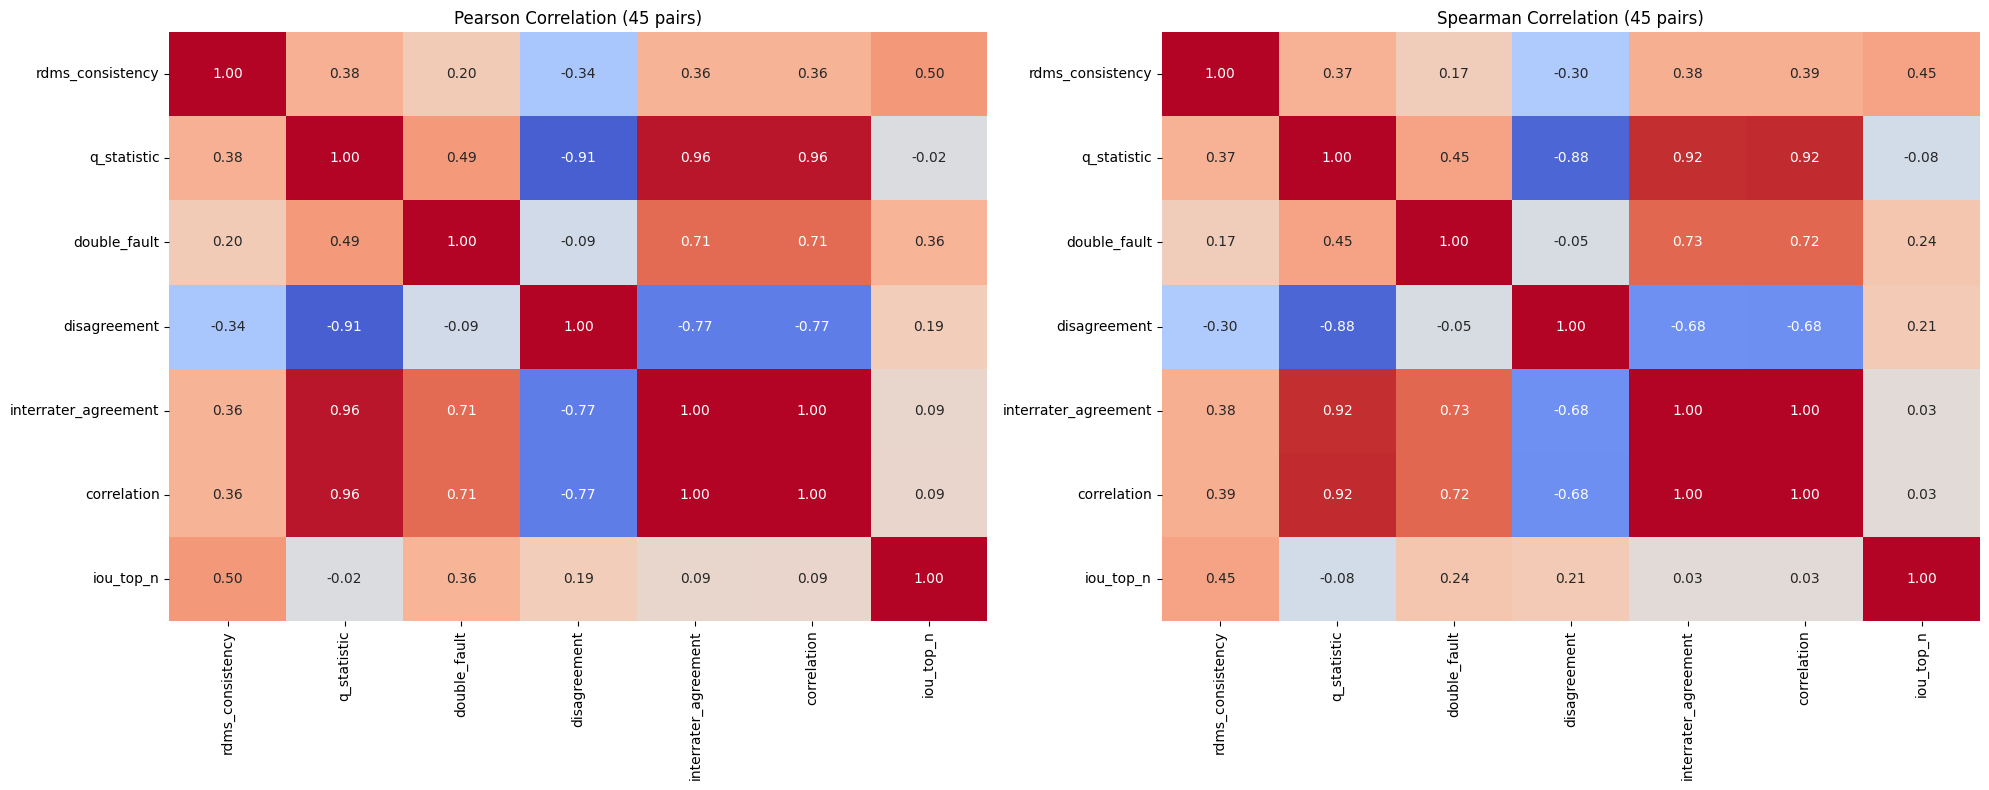

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# Create Analysis DataFrame (45 rows corresponding to the pairs)
df_pairs = pd.DataFrame(data)

# 2. Calculate Correlations
pearson_corr = df_pairs.corr(method='pearson')
spearman_corr = df_pairs.corr(method='spearman')

# Print simplifed view for verification
print("Spearman Correlation with Consistency:")
print(spearman_corr[['rdms_consistency']].sort_values(by='rdms_consistency', ascending=False))

# 3. Visualization
labels = pearson_corr.columns
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson Heatmap
sns.heatmap(pearson_corr, xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
            ax=axes[0], cbar=False)
axes[0].set_title("Pearson Correlation (45 pairs)")

# Spearman Heatmap
sns.heatmap(spearman_corr, xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, 
            ax=axes[1], cbar=False)
axes[1].set_title("Spearman Correlation (45 pairs)")

plt.tight_layout()

# Save and Show
# Handle __file__ for both script and notebook environments
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

fig_path = os.path.join(current_dir, 'metrics_correlation_matrix.png')
plt.savefig(fig_path, dpi=200)
plt.show()

print(f"Figure saved to {fig_path}")